# Forward Kinematics of a Quadruped Robot Leg

## What is Kinematics?

**Kinematics** is the study of motion *without* considering forces.  
In robotics it answers one question:

> *Given joint angles — where does the end-effector (foot) end up?*

There are two directions:

| | Input | Output |
|---|---|---|
| **Forward Kinematics (FK)** | Joint angles θ1, θ2, θ3 | Foot position (x, y, z) |
| **Inverse Kinematics (IK)** | Desired foot position (x, y, z) | Joint angles θ1, θ2, θ3 |

We start with **FK** — it is the foundation everything else builds on.


## Leg Structure

Each leg has **3 joints** and **3 links**:

```
Body Origin
    │
[Joint 1 — Hip Abduction θ1]  ← rotates around Z (left/right)
    │── Coxa (L1) ──
[Joint 2 — Hip Flexion  θ2]   ← rotates around Y (forward/back)
    │── Femur (L2) ──
[Joint 3 — Knee         θ3]   ← rotates around Y (forward/back)
    │── Tibia (L3) ──
  FOOT  ← this is what we want to find
```

**Link lengths used:**
- L1 (Coxa)  = 0.5 units
- L2 (Femur) = 1.0 units
- L3 (Tibia) = 1.0 units


## Building Blocks: Rotation & Homogeneous Transformation

### Rotation Matrix (3D)

A rotation matrix rotates a vector without changing its length.

**Around Z axis** (hip abduction — which direction the leg points):

$$R_z(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

**Around Y axis** (hip flexion and knee — up/down movement):

$$R_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$$

### Homogeneous Transformation Matrix (4×4)

Packs **rotation + translation** into one matrix:

$$T = \begin{bmatrix} R_{3\times3} & \vec{t}_{3\times1} \\ 0\ 0\ 0 & 1 \end{bmatrix}$$

### Chaining Joints (Forward Kinematics)

$$T_{foot} = T_1 \times T_2 \times T_3$$

The **last column** of $T_{foot}$ gives (x, y, z) of the foot.


## Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Rotation Matrices ──────────────────────────────────────────────────────────

def Rz(theta):
    """Rotation around Z axis (hip abduction — left/right swing of leg)"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, -s,  0,  0],
        [ s,  c,  0,  0],
        [ 0,  0,  1,  0],
        [ 0,  0,  0,  1]
    ])

def Ry(theta):
    """Rotation around Y axis (hip flexion / knee — up/down movement)"""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c,  0,  s,  0],
        [ 0,  1,  0,  0],
        [-s,  0,  c,  0],
        [ 0,  0,  0,  1]
    ])

def T_translate(x, y, z):
    """Pure translation matrix — moves along a link"""
    return np.array([
        [1, 0, 0, x],
        [0, 1, 0, y],
        [0, 0, 1, z],
        [0, 0, 0, 1]
    ])

print("Building blocks defined ✓")
print()
print("Rz(0°) — should be identity rotation:")
print(np.round(Rz(0), 3))
print()
print("Ry(90°) — x becomes z, z becomes -x:")
print(np.round(Ry(np.pi/2), 3))


Matplotlib is building the font cache; this may take a moment.


Building blocks defined ✓

Rz(0°) — should be identity rotation:
[[ 1. -0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

Ry(90°) — x becomes z, z becomes -x:
[[ 0.  0.  1.  0.]
 [ 0.  1.  0.  0.]
 [-1.  0.  0.  0.]
 [ 0.  0.  0.  1.]]


## Forward Kinematics Function

For each joint we build one homogeneous transform:

$$T_i = R_i(\theta_i) \times \text{Translate}(L_i)$$

Then chain: $T_{foot} = T_1 \times T_2 \times T_3$


In [2]:
# Link lengths (in arbitrary units — scale to your real robot later)
L1 = 0.5   # Coxa  (hip to first joint)
L2 = 1.0   # Femur (first to second joint)
L3 = 1.0   # Tibia (second to foot)


def get_joint_positions(theta1, theta2, theta3):
    """
    Forward Kinematics: given joint angles → returns positions of all joints.
    
    theta1 : hip abduction  (rotation around Z) — how far sideways the leg points
    theta2 : hip flexion    (rotation around Y) — how much upper leg tilts
    theta3 : knee angle     (rotation around Y) — how much lower leg bends
    
    Returns: list of 4 points [origin, joint1, joint2, foot]
    """
    # Origin (body attachment point)
    origin = np.array([0, 0, 0, 1])

    # ── Joint 1: Hip Abduction ──────────────────────────────────────────────
    # Rotate around Z by theta1, then translate along X by L1
    T1 = Rz(theta1) @ T_translate(L1, 0, 0)

    # ── Joint 2: Hip Flexion ────────────────────────────────────────────────
    # From joint1: rotate around Y by theta2, then translate along X by L2
    T2 = T1 @ Ry(theta2) @ T_translate(L2, 0, 0)

    # ── Joint 3: Knee ───────────────────────────────────────────────────────
    # From joint2: rotate around Y by theta3, then translate along X by L3
    T3 = T2 @ Ry(theta3) @ T_translate(L3, 0, 0)

    # Extract (x, y, z) positions from the last column of each transform
    p0 = np.array([0.0, 0.0, 0.0])        # origin
    p1 = T1[:3, 3]                          # after joint 1
    p2 = T2[:3, 3]                          # after joint 2
    p3 = T3[:3, 3]                          # foot (end effector)

    return p0, p1, p2, p3


# ── Quick test ─────────────────────────────────────────────────────────────────
t1, t2, t3 = np.radians(0), np.radians(0), np.radians(0)
p0, p1, p2, p3 = get_joint_positions(t1, t2, t3)

print("All joints at 0° — leg should be fully extended along X axis:")
print(f"  Origin  : {p0}")
print(f"  Joint 1 : {np.round(p1, 3)}")
print(f"  Joint 2 : {np.round(p2, 3)}")
print(f"  Foot    : {np.round(p3, 3)}")
print(f"  Expected foot x = L1+L2+L3 = {L1+L2+L3} ✓")


All joints at 0° — leg should be fully extended along X axis:
  Origin  : [0. 0. 0.]
  Joint 1 : [0.5 0.  0. ]
  Joint 2 : [1.5 0.  0. ]
  Foot    : [2.5 0.  0. ]
  Expected foot x = L1+L2+L3 = 2.5 ✓


## Visualise 3 Different Configurations

We plot three different joint angle combinations to see how FK maps angles → positions.


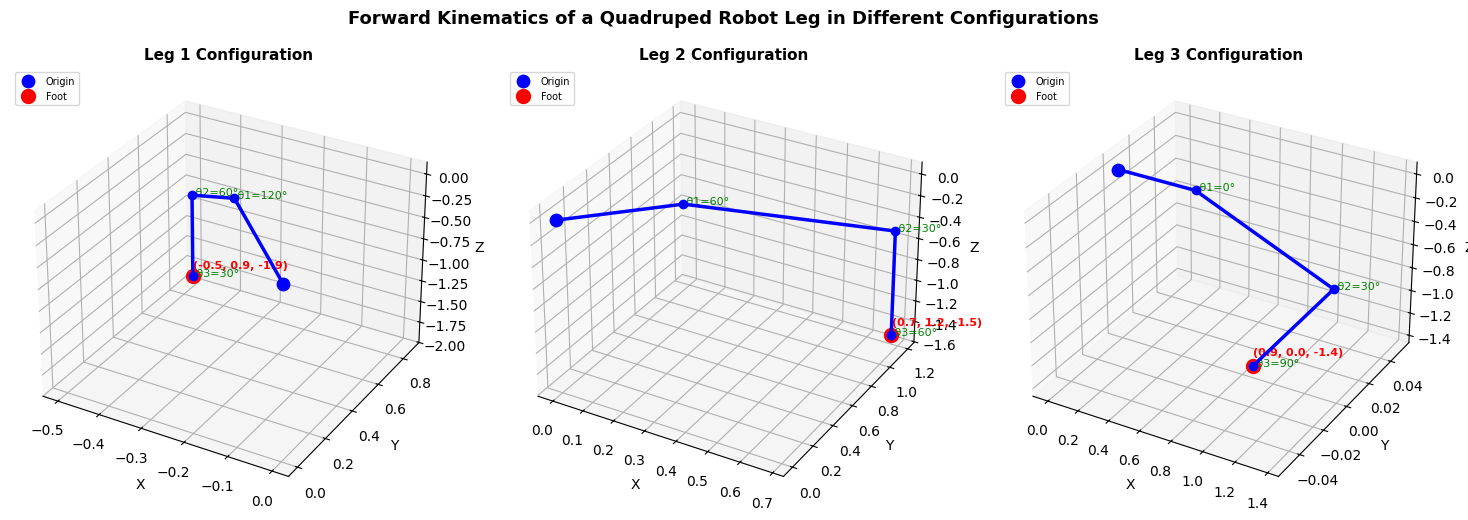

Plot saved ✓


In [3]:
# ── Three configurations to visualise ─────────────────────────────────────────
configurations = [
    {
        "label" : "Leg 1 Configuration",
        "theta1": 120,   # hip swings left
        "theta2": 60,    # hip flexed forward
        "theta3": 30,    # knee slightly bent
    },
    {
        "label" : "Leg 2 Configuration",
        "theta1": 60,    # hip points diagonally
        "theta2": 30,    # hip slightly flexed
        "theta3": 60,    # knee moderately bent
    },
    {
        "label" : "Leg 3 Configuration",
        "theta1": 0,     # leg points straight along X
        "theta2": 30,    # hip slightly flexed
        "theta3": 90,    # knee fully bent
    },
]


def plot_leg(ax, theta1_deg, theta2_deg, theta3_deg, title):
    """Plot a single leg configuration in 3D."""
    t1 = np.radians(theta1_deg)
    t2 = np.radians(theta2_deg)
    t3 = np.radians(theta3_deg)

    p0, p1, p2, p3 = get_joint_positions(t1, t2, t3)
    points = np.array([p0, p1, p2, p3])

    # Draw the leg links
    ax.plot(points[:, 0], points[:, 1], points[:, 2],
            'b-o', linewidth=2.5, markersize=6, zorder=5)

    # Highlight origin and foot
    ax.scatter(*p0, color='blue',   s=80,  zorder=10, label='Origin')
    ax.scatter(*p3, color='red',    s=100, zorder=10, label='Foot')

    # Annotate joint angles
    ax.text(*p1, f' θ1={theta1_deg}°', fontsize=8, color='green')
    ax.text(*p2, f' θ2={theta2_deg}°', fontsize=8, color='green')
    ax.text(*p3, f' θ3={theta3_deg}°', fontsize=8, color='green')

    # Annotate foot coordinates
    foot_label = f'({p3[0]:.1f}, {p3[1]:.1f}, {p3[2]:.1f})'
    ax.text(p3[0], p3[1], p3[2] + 0.1, foot_label, fontsize=8,
            color='red', fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend(loc='upper left', fontsize=7)


# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Forward Kinematics of a Quadruped Robot Leg in Different Configurations',
             fontsize=13, fontweight='bold', y=1.02)

for i, cfg in enumerate(configurations):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    plot_leg(ax, cfg["theta1"], cfg["theta2"], cfg["theta3"], cfg["label"])

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/forward_kinematics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")


## FK Results Table — All Configurations

In [4]:
print(f"{'Config':<25} {'θ1':>6} {'θ2':>6} {'θ3':>6}   {'Foot (x, y, z)'}")
print("-" * 65)

for cfg in configurations:
    t1 = np.radians(cfg["theta1"])
    t2 = np.radians(cfg["theta2"])
    t3 = np.radians(cfg["theta3"])
    _, _, _, foot = get_joint_positions(t1, t2, t3)
    print(f"{cfg['label']:<25} {cfg['theta1']:>5}° {cfg['theta2']:>5}° {cfg['theta3']:>5}°   "
          f"({foot[0]:+.3f}, {foot[1]:+.3f}, {foot[2]:+.3f})")


Config                        θ1     θ2     θ3   Foot (x, y, z)
-----------------------------------------------------------------
Leg 1 Configuration         120°    60°    30°   (-0.500, +0.866, -1.866)
Leg 2 Configuration          60°    30°    60°   (+0.683, +1.183, -1.500)
Leg 3 Configuration           0°    30°    90°   (+0.866, +0.000, -1.366)


## Manual Verification — Leg 3 (θ1=0°, θ2=30°, θ3=90°)

Let's verify Leg 3 by hand to confirm the code is correct.

Since θ1=0°, the leg stays in the **XZ plane** (y=0 throughout).

The 4×4 chain reduces to 2D geometry in that plane.


In [5]:
# Manual check for Leg 3: theta1=0, theta2=30, theta3=90
theta1 = np.radians(0)
theta2 = np.radians(30)
theta3 = np.radians(90)

# ── Step 1: T1 (hip abduction, theta1=0 → no rotation) ────────────────────────
T1 = Rz(theta1) @ T_translate(L1, 0, 0)
print("T1 (after Coxa):")
print(np.round(T1, 3))
print(f"  Joint 1 position: {np.round(T1[:3,3], 3)}")

# ── Step 2: T2 (hip flexion, theta2=30°) ──────────────────────────────────────
T2 = T1 @ Ry(theta2) @ T_translate(L2, 0, 0)
print()
print("T2 (after Femur):")
print(np.round(T2, 3))
print(f"  Joint 2 position: {np.round(T2[:3,3], 3)}")

# ── Step 3: T3 (knee, theta3=90°) ─────────────────────────────────────────────
T3 = T2 @ Ry(theta3) @ T_translate(L3, 0, 0)
print()
print("T3 (foot / end effector):")
print(np.round(T3, 3))
print(f"  Foot position: {np.round(T3[:3,3], 3)}")

print()
print("✓ y = 0 (expected, since theta1 = 0°)")
print("✓ Rotation part of T3 encodes total orientation of foot link")


T1 (after Coxa):
[[1.  0.  0.  0.5]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  1. ]]
  Joint 1 position: [0.5 0.  0. ]

T2 (after Femur):
[[ 0.866  0.     0.5    1.366]
 [ 0.     1.     0.     0.   ]
 [-0.5    0.     0.866 -0.5  ]
 [ 0.     0.     0.     1.   ]]
  Joint 2 position: [ 1.366  0.    -0.5  ]

T3 (foot / end effector):
[[-0.5    0.     0.866  0.866]
 [ 0.     1.     0.     0.   ]
 [-0.866  0.    -0.5   -1.366]
 [ 0.     0.     0.     1.   ]]
  Foot position: [ 0.866  0.    -1.366]

✓ y = 0 (expected, since theta1 = 0°)
✓ Rotation part of T3 encodes total orientation of foot link


## Summary

| Step | What we did | Tool used |
|---|---|---|
| 1 | Defined each joint as a rotation | Rotation matrix Rz / Ry |
| 2 | Added link length as translation | Homogeneous transform T |
| 3 | Chained joints: T1 × T2 × T3 | Matrix multiplication |
| 4 | Read foot position from last column | T[:3, 3] |

**Key rule:**  
The last column of the final transform = **(x, y, z)** of the end effector.

---

### What comes next — Inverse Kinematics

FK answers: *"I have angles — where is my foot?"*  
IK answers: *"I want my foot here — what angles do I need?"*

For a 3-DOF leg the IK can be solved analytically:
1. **θ1** from `atan2(y_foot, x_foot)` — hip abduction
2. **θ2, θ3** from the cosine rule in the sagittal plane — like a 2-link arm
